In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP
import sklearn
import seaborn as sns
from process import SpaHDSRL
import warnings
warnings.filterwarnings('ignore')
random_seed = 20

In [ ]:
# read data
file_fold = './tutorial5/' #please replace 'file_fold' with the download path

adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ADT.h5ad')
adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()


def ensure_ndarray_X(adata):
    X = adata.X
    if sp.issparse(X):
        adata.X = X.toarray().astype(np.float32)   
    else:
        adata.X = np.asarray(X, dtype=np.float32)  
    return adata

adata_omics1 = ensure_ndarray_X(adata_omics1)
adata_omics2 = ensure_ndarray_X(adata_omics2)

In [ ]:
SpaHDSRL_result = SpaHDSRL(adata1=adata_omics1,adata2=adata_omics2)
SpaHDSRL_result.preprocessing_data(do_norm=True, n_neighbors = 5)
SpaHDSRL_result.train(spatial_regularization_strength=0.01, z_dim=50, 
         lr=1e-3, wnn_epoch = 500, total_epoch=300, max_patience_bef=10, max_patience_aft=30, min_stop=200, 
         random_seed=random_seed, gpu=0, regularization_acceleration=True, edge_subset_sz=1000000, k_neighbors=5, gamma=0.05)
df_embedding = pd.DataFrame(SpaHDSRL_result.embedding)

Epoch 1/300, Loss: 1.3884793519973755
Epoch 11/300, Loss: 1.3380399942398071
Epoch 21/300, Loss: 1.2024388313293457
Epoch 31/300, Loss: 1.0473005771636963
Epoch 41/300, Loss: 0.8357545733451843
Epoch 51/300, Loss: 0.6351559162139893
Epoch 61/300, Loss: 0.4880865812301636
Epoch 71/300, Loss: 0.34536346793174744
Epoch 81/300, Loss: 0.2369542270898819
Epoch 91/300, Loss: 0.18756571412086487
Epoch 101/300, Loss: 0.1661958396434784
Epoch 111/300, Loss: 0.12196937948465347
Epoch 121/300, Loss: 0.10543050616979599
Epoch 131/300, Loss: 0.08851075172424316
Epoch 141/300, Loss: 0.07304739207029343
Epoch 151/300, Loss: 0.05803552269935608
Epoch 161/300, Loss: 0.04548106715083122
Epoch 171/300, Loss: 0.04013702645897865
Epoch 181/300, Loss: 0.03493861109018326
Epoch 191/300, Loss: 0.03030562773346901
Epoch 201/300, Loss: 0.028369350358843803
Epoch 211/300, Loss: 0.03597404062747955
Epoch 221/300, Loss: 0.025836504995822906
Epoch 231/300, Loss: 0.022623198106884956
Epoch 241/300, Loss: 0.0206903833

In [4]:
def screen_res(df_embedding, n_cluster = 5, res_s = 0.1, res_e = 1.0, step = 0.1):
    opt_res = res_s
    opt_clusters = n_cluster
    for res in np.arange(res_s,res_e,step):
        embedding_adata = sc.AnnData(df_embedding)
        sc.pp.neighbors(embedding_adata, n_neighbors=50, use_rep='X')
        sc.tl.leiden(embedding_adata, resolution=float(res))
        clusters = list(embedding_adata.obs["leiden"])
        cluster_num = len(np.unique(clusters))
        print('res = ' + str(round(res, 2)) + ', Cluster# = ' + str(cluster_num))
        if cluster_num == n_cluster:
            opt_res = res
            opt_clusters = clusters
    print('optimal res = ' + str(round(opt_res, 2)))
    return opt_res, opt_clusters

# Screening resoluti on that matches the given number of clusters 
opt_res_SpaHDSRL, opt_clusters_SpaHDSRL = screen_res(df_embedding,res_s = 0.3, res_e = 0.5, step = 0.01,n_cluster = 8)

res = 0.3, Cluster# = 8
res = 0.31, Cluster# = 7
res = 0.32, Cluster# = 6
res = 0.33, Cluster# = 7
res = 0.34, Cluster# = 8
res = 0.35, Cluster# = 8
res = 0.36, Cluster# = 9
res = 0.37, Cluster# = 9
res = 0.38, Cluster# = 9
res = 0.39, Cluster# = 9
res = 0.4, Cluster# = 9
res = 0.41, Cluster# = 10
res = 0.42, Cluster# = 10
res = 0.43, Cluster# = 10
res = 0.44, Cluster# = 10
res = 0.45, Cluster# = 9
res = 0.46, Cluster# = 9
res = 0.47, Cluster# = 9
res = 0.48, Cluster# = 10
res = 0.49, Cluster# = 10
optimal res = 0.35


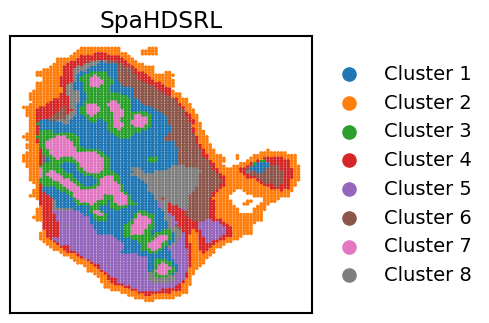

In [5]:
adata_new = adata_omics1.copy()
adata_new.obs["Cluster_SpaHDSRL"] = opt_clusters_SpaHDSRL
adata_plot = adata_new.copy()

cl = adata_plot.obs["Cluster_SpaHDSRL"].astype(str)
if set(cl.unique()).issubset(set([str(i) for i in range(1000)])):
    cl_int = cl.astype(int) + 1
    adata_plot.obs["Cluster_show"] = pd.Categorical(["Cluster %d" % i for i in cl_int])
else:
    adata_plot.obs["Cluster_show"] = pd.Categorical(["Cluster " + x for x in cl])

cats = sorted(adata_plot.obs["Cluster_show"].cat.categories,
              key=lambda x: int(x.split()[-1]) if x.split()[-1].isdigit() else x)
adata_plot.obs["Cluster_show"] = adata_plot.obs["Cluster_show"].cat.reorder_categories(cats, ordered=True)


plt.rcParams["font.family"] = "DejaVu Sans"   
plt.rcParams["font.size"] = 14

fig, ax = plt.subplots(1, 1, figsize=(3.9, 3.6))
title = "SpaHDSRL"

sc.pl.embedding(
    adata_plot,
    basis="spatial",
    color="Cluster_show",
    ax=ax,
    show=False,
    title=title,
    size=28,               
    frameon=True,
    legend_loc="right margin"
)
ax.invert_yaxis()


ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])


for spine in ax.spines.values():
    spine.set_linewidth(1.5)

leg = ax.get_legend()
if leg is not None:
    leg.set_title("")                  
    leg._loc = 6                       
    for h in leg.legend_handles:
        try:
            h.set_sizes([90])          
        except Exception:
            pass

plt.show()

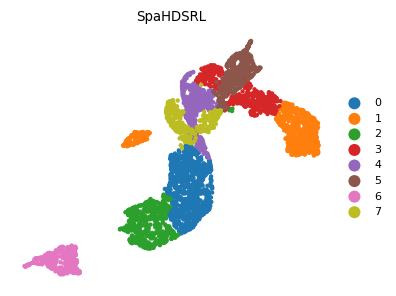

In [6]:
# UMAP visualization
umap_2d = UMAP(n_components=2, init='random', random_state=random_seed, min_dist = 0.3,n_neighbors=30)
umap_pos = umap_2d.fit_transform(df_embedding)
adata_new.obs['SpaHDSRL_umap_pos_x'] = umap_pos[:,0]
adata_new.obs['SpaHDSRL_umap_pos_y'] = umap_pos[:,1]

# Ploting figures
plot_color = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#bcbd22", "#17becf", "#ffbb78"
]
matplotlib.rcParams['font.size'] = 8.0
fig, axes = plt.subplots(1, 1, figsize=(4,3))
sz = 40
domains="Cluster_SpaHDSRL"
num_celltype=len(adata_new.obs[domains].unique())
adata_new.uns[domains+"_colors"]=list(plot_color[:num_celltype])
titles = 'SpaHDSRL'
ax=sc.pl.scatter(adata_new,alpha=1,x="SpaHDSRL_umap_pos_x",y="SpaHDSRL_umap_pos_y",color=domains,title=titles ,color_map=plot_color,show=False,size=sz,ax = axes)
ax.axis('off')
plt.tight_layout()